Dataset shape: (500, 15)

First 5 rows:
Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            500 non-null    int64  
 1   Title           500 non-null    object 
 2   Author          500 non-null    object 
 3   Category        500 non-null    object 
 4   Sub-Genre       500 non-null    object 
 5   Format          500 non-null    object 
 6   Price (USD)     500 non-null    float64
 7   Rating          500 non-null    float64
 8   Reviews         500 non-null    float64
 9   Weeks on List   500 non-null    float64
 10  Publisher       500 non-null    object 
 11  Year Published  500 non-null    float64
 12  ISBN            500 non-null    object 
 13  Amazon BSR      500 non-null    float64
 14  Amazon URL      500 non-null    object 
dtypes: float64(6), int64(1), object(8)
memory usage: 58.7

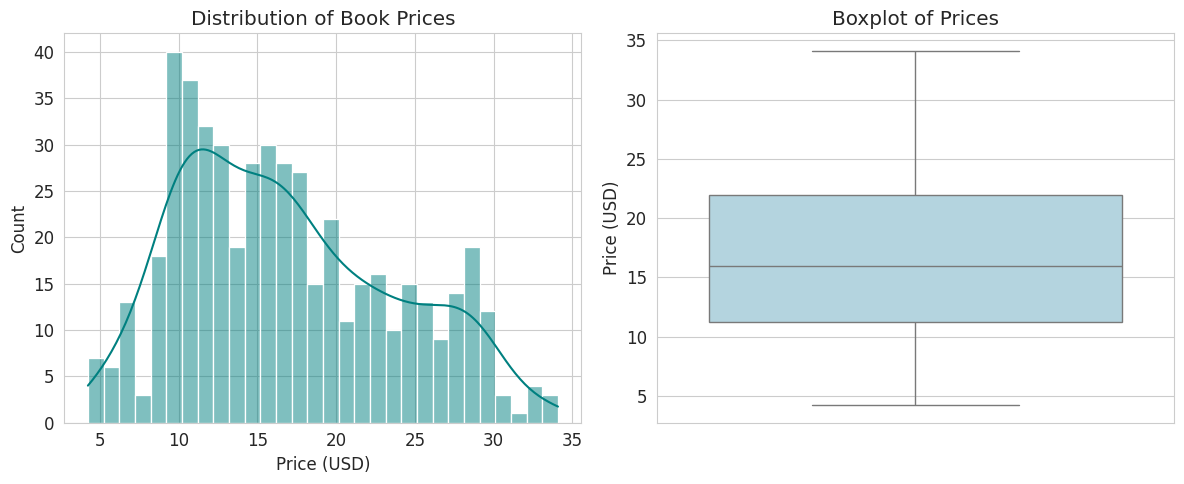

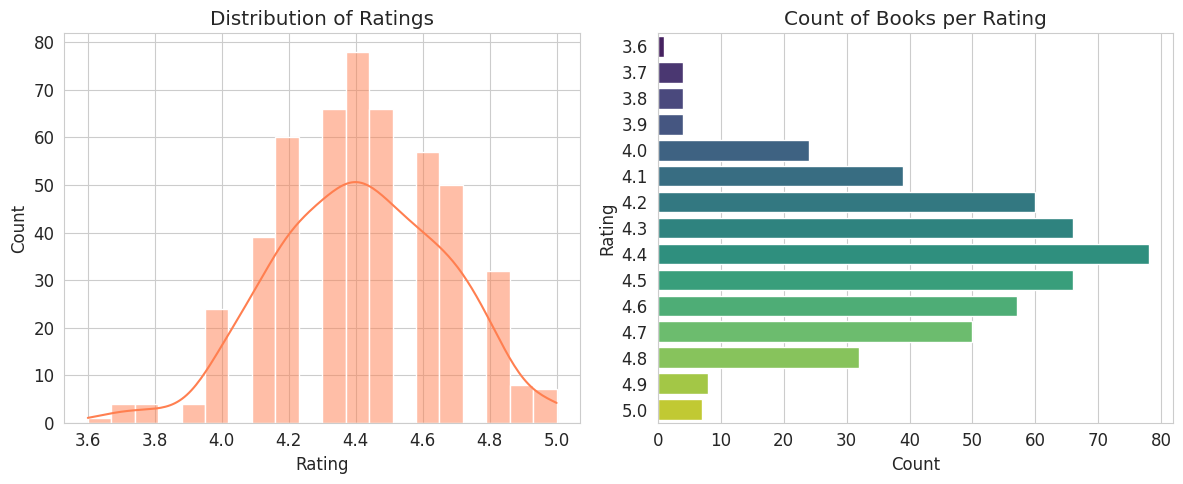

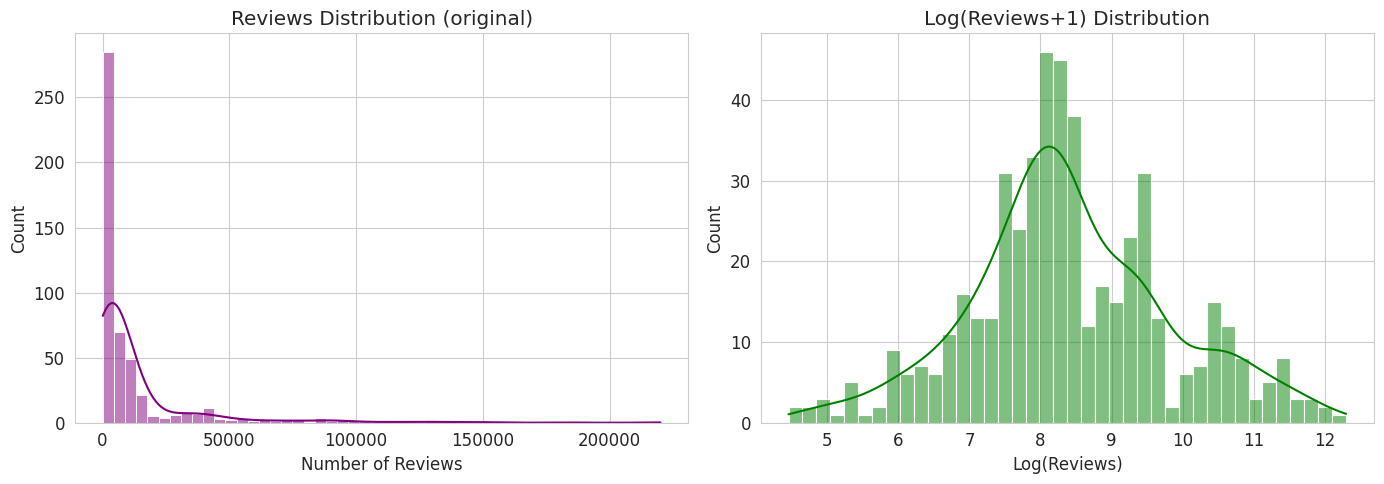

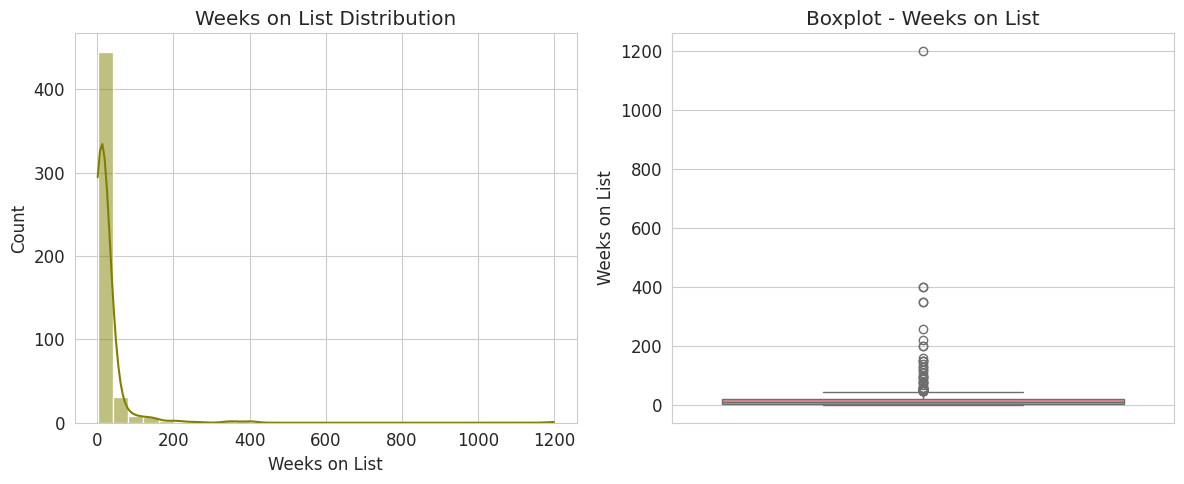

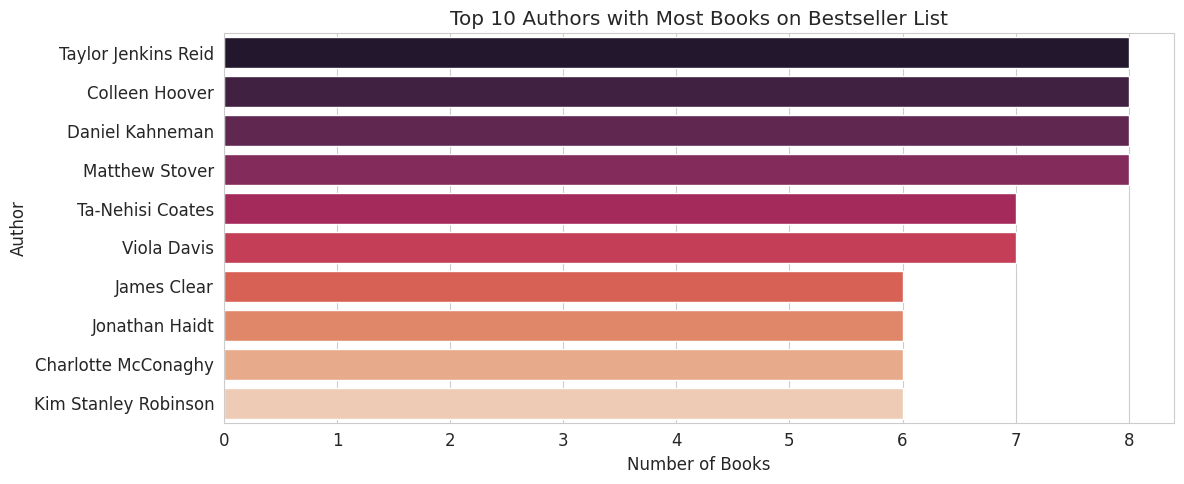

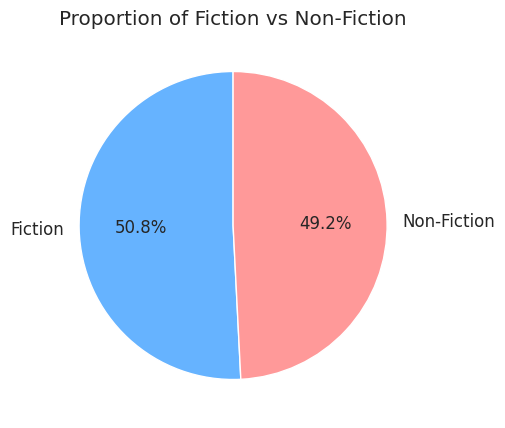

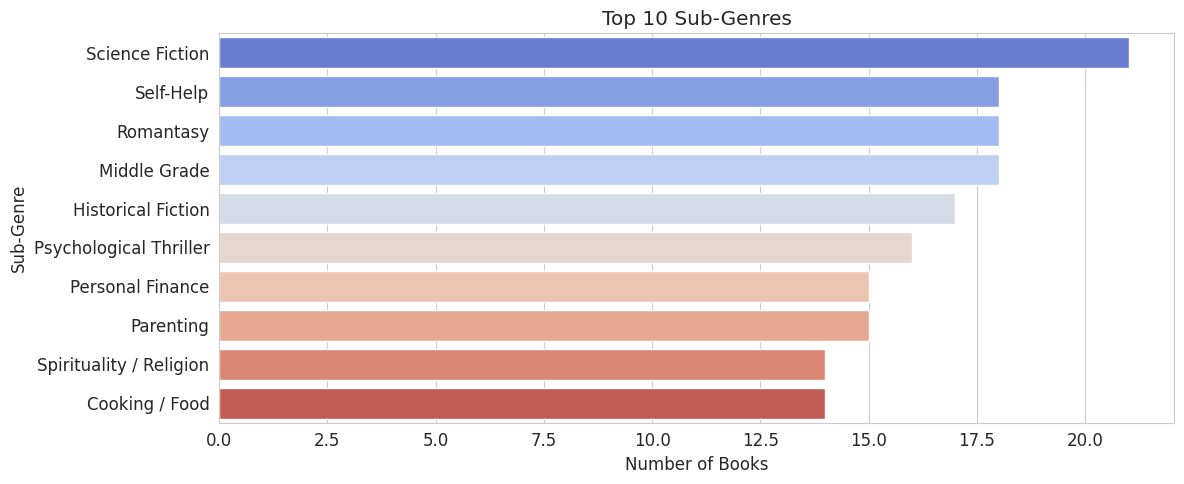

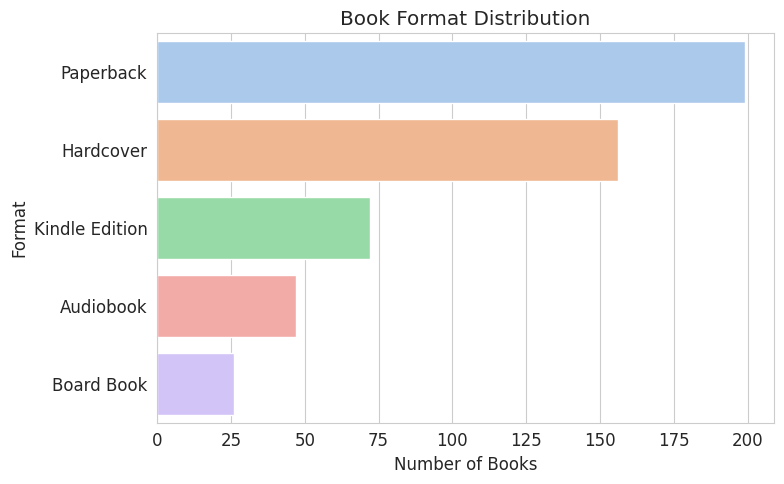

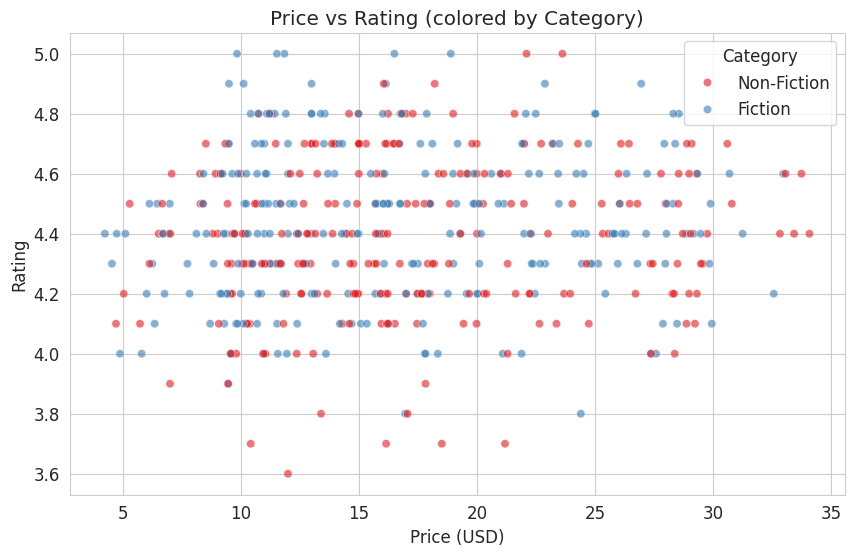

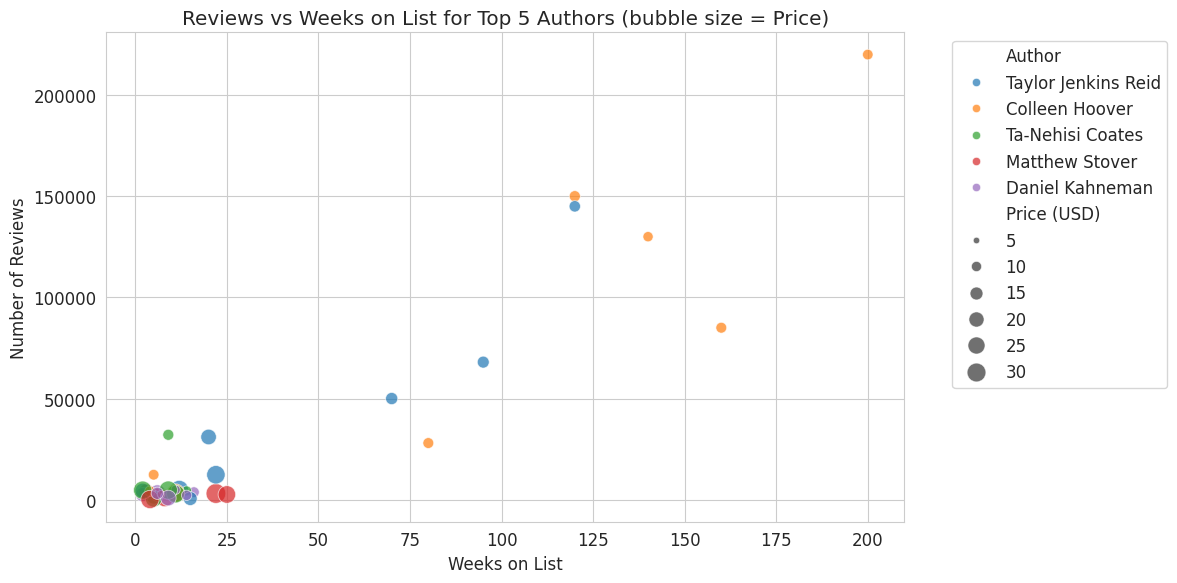

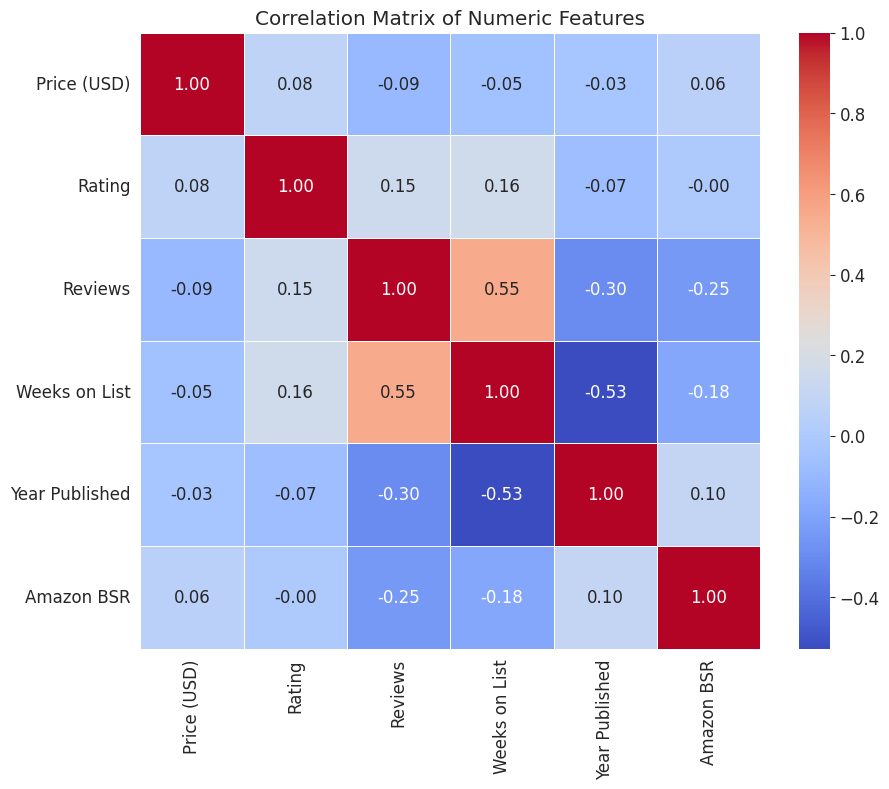

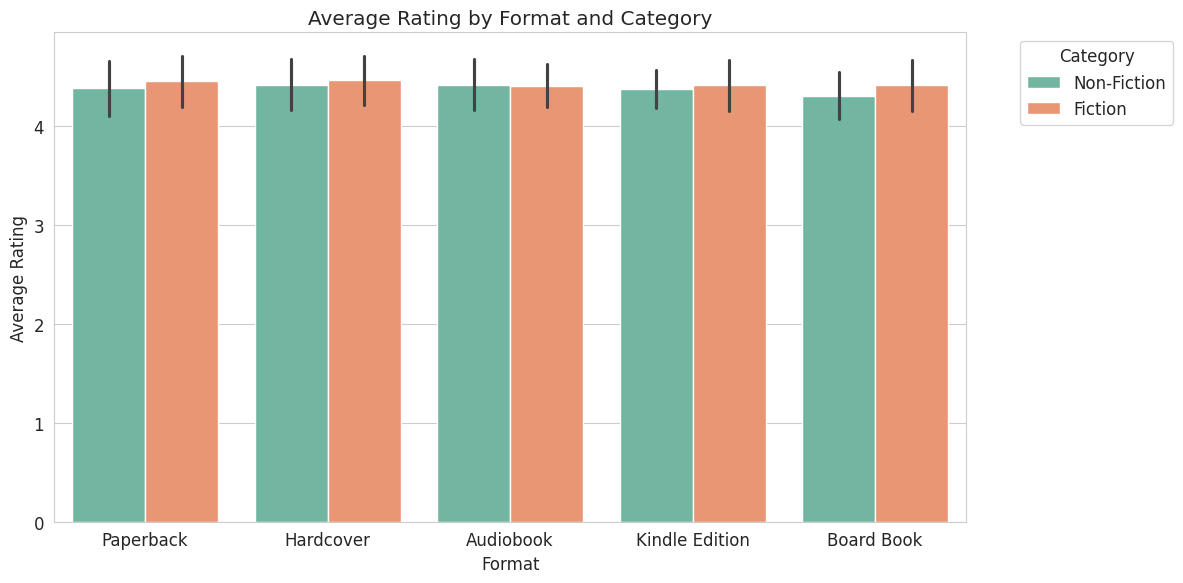

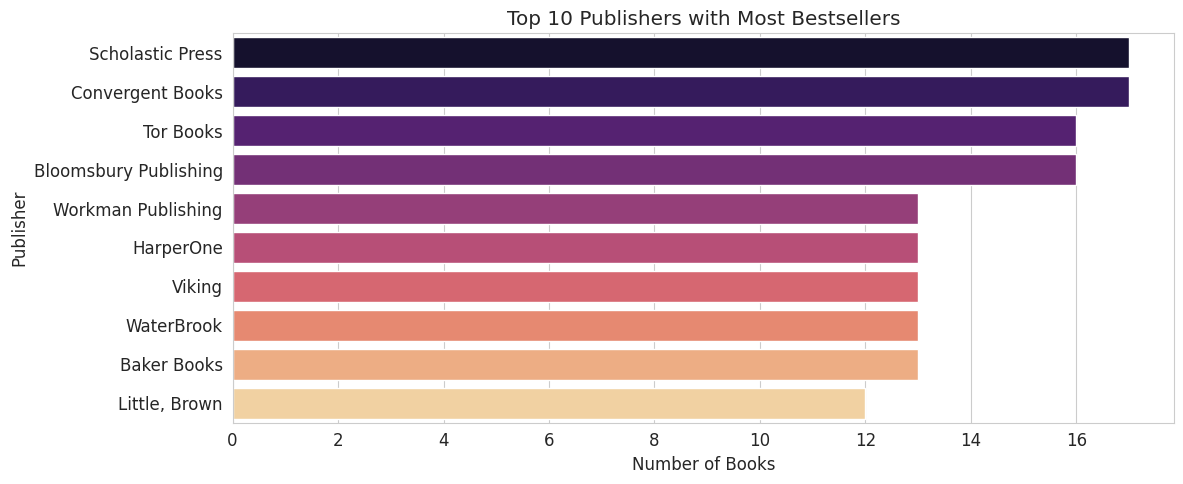


Top 10 Publishers - Average Price and Rating:
                       Price (USD)  Rating
Publisher                                 
Baker Books                  17.08    4.35
Bloomsbury Publishing        17.71    4.49
Convergent Books             18.14    4.38
HarperOne                    17.62    4.46
Little, Brown                16.76    4.25
Scholastic Press             15.93    4.40
Tor Books                    15.06    4.34
Viking                       17.13    4.39
WaterBrook                   16.93    4.35
Workman Publishing           11.40    4.38


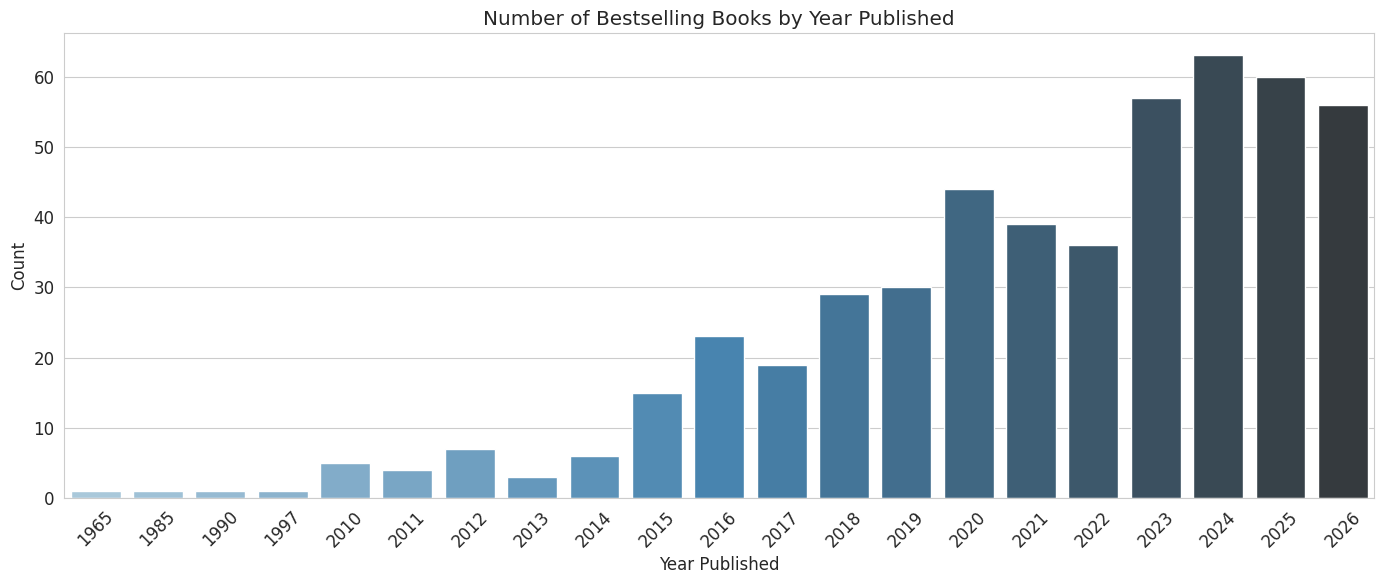


EDA completed successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 1. Load the dataset
file_path = '/kaggle/input/datasets/shambhurajejagadale/amazon-bestselling-books-dataset-500-books/Amazon_BestSelling_Books_500.csv'
df = pd.read_csv(file_path)

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

# 2. Data Overview
print("Data Types and Non-Null Counts:")
df.info()

print("\nStatistical Summary (numeric columns):")
df.describe()

# 3. Check for missing values
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_table = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print(missing_table[missing_table['Missing Count'] > 0])

# 4. Data Cleaning
df['Price (USD)'] = df['Price (USD)'].replace(r'[\$,]', '', regex=True).astype(float)

# Ensure 'Reviews' and 'Weeks on List' are numeric 
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Weeks on List'] = pd.to_numeric(df['Weeks on List'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Year Published'] = pd.to_numeric(df['Year Published'], errors='coerce')

# Drop rows where essential numeric columns are missing 
df_clean = df.dropna(subset=['Price (USD)', 'Rating', 'Reviews', 'Weeks on List']).copy()

print(f"Rows after dropping essential missing values: {len(df_clean)} (original: {len(df)})")

# 5. Top 20 Highest Rated Books
print("\n" + "="*70)
print("TOP 20 HIGHEST RATED BOOKS (sorted by Rating, then by Reviews)")
print("="*70)

# Sort by Rating descending, then by Reviews descending to break ties
top_rated = df_clean.sort_values(['Rating', 'Reviews'], ascending=[False, False]).head(20)

# Select relevant columns for display
display_cols = ['Rank', 'Title', 'Author', 'Rating', 'Reviews', 'Category', 'Sub-Genre', 'Price (USD)']
top_rated_display = top_rated[display_cols].copy()
top_rated_display['Rating'] = top_rated_display['Rating'].round(2)
print(top_rated_display.to_string(index=False))

# 6. Univariate Analysis

# 6.1 Distribution of Book Prices
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_clean['Price (USD)'], bins=30, kde=True, color='teal')
plt.title('Distribution of Book Prices')
plt.xlabel('Price (USD)')

plt.subplot(1,2,2)
sns.boxplot(y=df_clean['Price (USD)'], color='lightblue')
plt.title('Boxplot of Prices')
plt.tight_layout()
plt.show()

# 6.2 Rating Distribution
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_clean['Rating'], bins=20, kde=True, color='coral')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')

plt.subplot(1,2,2)
sns.countplot(y=df_clean['Rating'].round(1), order=sorted(df_clean['Rating'].dropna().round(1).unique()), palette='viridis')
plt.title('Count of Books per Rating')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

# 6.3 Reviews and Weeks on List 
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(df_clean['Reviews'], bins=50, ax=axes[0], color='purple', kde=True)
axes[0].set_title('Reviews Distribution (original)')
axes[0].set_xlabel('Number of Reviews')

sns.histplot(np.log1p(df_clean['Reviews']), bins=40, ax=axes[1], color='green', kde=True)
axes[1].set_title('Log(Reviews+1) Distribution')
axes[1].set_xlabel('Log(Reviews)')
plt.tight_layout()
plt.show()

# 6.4 Weeks on List
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_clean['Weeks on List'], bins=30, kde=True, color='olive')
plt.title('Weeks on List Distribution')
plt.subplot(1,2,2)
sns.boxplot(y=df_clean['Weeks on List'], color='lightcoral')
plt.title('Boxplot - Weeks on List')
plt.tight_layout()
plt.show()

# 7. Categorical Analysis

# 7.1 Top Authors (by number of books)
top_authors = df_clean['Author'].value_counts().head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='rocket')
plt.title('Top 10 Authors with Most Books on Bestseller List')
plt.xlabel('Number of Books')
plt.tight_layout()
plt.show()

# 7.2 Category Distribution
category_counts = df_clean['Category'].value_counts()
plt.figure(figsize=(8,5))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Proportion of Fiction vs Non-Fiction')
plt.show()

# 7.3 Sub-Genre (top 10)
subgenre_counts = df_clean['Sub-Genre'].value_counts().head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=subgenre_counts.values, y=subgenre_counts.index, palette='coolwarm')
plt.title('Top 10 Sub-Genres')
plt.xlabel('Number of Books')
plt.tight_layout()
plt.show()

# 7.4 Format Distribution
format_counts = df_clean['Format'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=format_counts.values, y=format_counts.index, palette='pastel')
plt.title('Book Format Distribution')
plt.xlabel('Number of Books')
plt.tight_layout()
plt.show()

# 8. Bivariate & Multivariate Analysis

# 8.1 Price vs Rating
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='Price (USD)', y='Rating', alpha=0.6, hue='Category', palette='Set1')
plt.title('Price vs Rating (colored by Category)')
plt.show()

# 8.2 Reviews vs Weeks on List (top authors)
top_author_list = top_authors.index[:5]
df_top_authors = df_clean[df_clean['Author'].isin(top_author_list)]
plt.figure(figsize=(12,6))
sns.scatterplot(data=df_top_authors, x='Weeks on List', y='Reviews', hue='Author', size='Price (USD)', sizes=(20,200), alpha=0.7)
plt.title('Reviews vs Weeks on List for Top 5 Authors (bubble size = Price)')
plt.xlabel('Weeks on List')
plt.ylabel('Number of Reviews')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 8.3 Correlation Matrix (numeric columns)
numeric_cols = ['Price (USD)', 'Rating', 'Reviews', 'Weeks on List', 'Year Published', 'Amazon BSR']
corr_matrix = df_clean[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# 8.4 Average Rating by Category and Format
plt.figure(figsize=(12,6))
sns.barplot(data=df_clean, x='Format', y='Rating', hue='Category', palette='Set2', errorbar='sd')
plt.title('Average Rating by Format and Category')
plt.ylabel('Average Rating')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 9. Publisher Analysis
top_publishers = df_clean['Publisher'].value_counts().head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='magma')
plt.title('Top 10 Publishers with Most Bestsellers')
plt.xlabel('Number of Books')
plt.tight_layout()
plt.show()

# Average price and rating by publisher (top 10 by count)
publisher_stats = df_clean[df_clean['Publisher'].isin(top_publishers.index)].groupby('Publisher').agg({'Price (USD)': 'mean', 'Rating': 'mean'}).round(2)
print("\nTop 10 Publishers - Average Price and Rating:")
print(publisher_stats)

# 10. Year Published Trends 
year_counts = df_clean['Year Published'].value_counts().sort_index()
plt.figure(figsize=(14,6))
sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, palette='Blues_d')
plt.title('Number of Bestselling Books by Year Published')
plt.xlabel('Year Published')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nEDA completed successfully!")